# 초기 관문 난이도가 사용자 활성화 및 장기 잔존에 미치는 영향 분석

모바일 게임 Cookie Cats에서의 A/B 테스트 데이터를 활용하여,

첫 번째 주요 관문(Gate)을 30레벨 → 40레벨로 변경했을 때  
유저의 플레이 행동과 잔존율에 어떤 변화가 발생했는지 분석하는 것을 목적으로 한다.
###### 분석기간 : 2025.12 / 2026.02(추가분석)

## 분석 배경

게임에서 특정 레벨 구간의 난이도 설계는  
유저의 이탈률과 몰입도에 직접적인 영향을 미친다.  

게임 설치 시 유저는 무작위로 30레벨 관문 시작, 40레벨 관문 시작하는 그룹 중 하나에 배정되었다.  
  
이를 통해 관문 위치 변경이 유저 유지에 미치는 영향을 검증한다.  
관문은 일정 시간 대기 혹은 결제 유도를 통해  
게임 수익과 난이도 밸런스를 조정하는 핵심 장치이다.  
  
관문 위치 변경은 **초기 플레이 경험**,**몰입 형성 구간**,**장기 유저 유지율** 에 중요한 영향을 미친다.  

## 활용 기술
Python : 데이터 분석  
PySpark : 대규모 로그 처리 가정 분석   
Pandas : 데이터 전처리   
Matplotlib : 시각화  

## 데이터 설명

해당 데이터는 A/B 테스트가 진행된 기간 동안  
총 90,189명 유저의 플레이 로그를 포함한다.  

주요 변수  

- userid : 유저ID  
- version : A/B 실험 그룹  
    - gate_30   
    - gate_40  
- sum_gamerounds : 설치 후 14일 동안 플레이한 총 게임 라운드 수  
- retention_1 : 설치 1일 후 재접속 여부  
- retention_7 : 설치 7일 후 재접속 여부  

## 데이터 확인 및 전처리

### 데이터 확인

In [5]:
from pyspark.sql import SparkSession
import  pyspark.sql.functions as F

In [6]:
spark = SparkSession.builder \
    .appName("CSV_Load_Test") \
    .getOrCreate()

sdf = spark.read.csv(
    "C:/Users/LEe/project/retention/data/cookie_cats.csv",
    header=True,
    inferSchema=True
)

sdf.createOrReplaceTempView("t")

In [7]:
sdf.printSchema()
print(sdf.count())

root
 |-- userid: integer (nullable = true)
 |-- version: string (nullable = true)
 |-- sum_gamerounds: integer (nullable = true)
 |-- retention_1: boolean (nullable = true)
 |-- retention_7: boolean (nullable = true)

90189


In [8]:
sdf.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in sdf.columns]).show()

+------+-------+--------------+-----------+-----------+
|userid|version|sum_gamerounds|retention_1|retention_7|
+------+-------+--------------+-----------+-----------+
|     0|      0|             0|          0|          0|
+------+-------+--------------+-----------+-----------+



In [9]:
sdf.select(F.min("sum_gamerounds").alias("MIN")
           ,F.max("sum_gamerounds").alias("MAX")
           ,F.avg("sum_gamerounds").alias("AVG")).show()

+---+-----+----------------+
|MIN|  MAX|             AVG|
+---+-----+----------------+
|  0|49854|51.8724567297564|
+---+-----+----------------+



- 결측치 X
- 평균게임판수는 약 52판
-   최소0판 <- 설치만 한 유저  
    최대는 49854판 <- 2주만에 49854개를 깻다는 것이 이상함.

### 데이터 전처리

#### 1. 이상치 제거 + retention_1&retention_7 타입 변경

In [10]:
sdf.approxQuantile("sum_gamerounds", [0.5, 0.9, 0.99, 0.995, 0.999], 0.001)
# 분포 체크 : 99%에서 99.9% 차이가 너무 큼 -> 49854값이 너무 튀었다는 것을 알 수 있음.

[16.0, 134.0, 490.0, 601.0, 49854.0]

In [11]:
sdf.orderBy("sum_gamerounds", ascending=False).show()

+-------+-------+--------------+-----------+-----------+
| userid|version|sum_gamerounds|retention_1|retention_7|
+-------+-------+--------------+-----------+-----------+
|6390605|gate_30|         49854|      false|       true|
| 871500|gate_30|          2961|       true|       true|
|3271615|gate_40|          2640|       true|      false|
|4832608|gate_30|          2438|       true|       true|
|5346171|gate_40|          2294|       true|       true|
|5133952|gate_30|          2251|       true|       true|
|9640085|gate_30|          2156|       true|       true|
|4090246|gate_40|          2124|       true|       true|
|9791599|gate_40|          2063|       true|       true|
| 725080|gate_40|          2015|       true|       true|
|  69927|gate_30|          1906|       true|       true|
|2067556|gate_40|          1816|       true|       true|
|3064157|gate_30|          1714|       true|       true|
|1476122|gate_30|          1705|       true|       true|
|1310015|gate_40|          1697

In [12]:
max_val = sdf.agg(F.max("sum_gamerounds")).collect()[0][0]
sdf_1 = sdf.filter(F.col("sum_gamerounds") != max_val)
sdf_1 = (sdf_1
        .withColumn("retention_1",F.col("retention_1").cast("int"))
        .withColumn("retention_7",F.col("retention_7").cast("int")))

In [13]:
sdf_1.show()

+------+-------+--------------+-----------+-----------+
|userid|version|sum_gamerounds|retention_1|retention_7|
+------+-------+--------------+-----------+-----------+
|   116|gate_30|             3|          0|          0|
|   337|gate_30|            38|          1|          0|
|   377|gate_40|           165|          1|          0|
|   483|gate_40|             1|          0|          0|
|   488|gate_40|           179|          1|          1|
|   540|gate_40|           187|          1|          1|
|  1066|gate_30|             0|          0|          0|
|  1444|gate_40|             2|          0|          0|
|  1574|gate_40|           108|          1|          1|
|  1587|gate_40|           153|          1|          0|
|  1842|gate_40|             3|          0|          1|
|  2101|gate_30|             0|          0|          0|
|  2132|gate_40|            30|          1|          0|
|  2179|gate_30|            39|          1|          0|
|  2218|gate_30|           305|          1|     

In [14]:
sdf_1.select(F.min("sum_gamerounds").alias("MIN")
           ,F.max("sum_gamerounds").alias("MAX")
           ,F.avg("sum_gamerounds").alias("AVG")).show()

+---+----+-----------------+
|MIN| MAX|              AVG|
+---+----+-----------------+
|  0|2961|51.32025324876924|
+---+----+-----------------+



평균 판수는 약 51판  
최대는 2961판 <- 하루에 약 212판 정도 클리어

#### 2. 게임 설치한 후 플레이 이력이 없는 유저 제거한 데이터

In [15]:
sdf.filter(F.col("sum_gamerounds") ==0).count()

3994

In [16]:
sdf_2 = sdf_1.filter(F.col("sum_gamerounds") != 0)

In [17]:
sdf_2.orderBy("sum_gamerounds",ascending=True).show()

+------+-------+--------------+-----------+-----------+
|userid|version|sum_gamerounds|retention_1|retention_7|
+------+-------+--------------+-----------+-----------+
| 13872|gate_30|             1|          0|          0|
| 14592|gate_30|             1|          0|          0|
|  9828|gate_40|             1|          0|          0|
| 17461|gate_30|             1|          0|          0|
|  5066|gate_30|             1|          0|          0|
| 17554|gate_30|             1|          0|          0|
|  6156|gate_40|             1|          0|          0|
| 18731|gate_30|             1|          0|          0|
|  9849|gate_40|             1|          0|          0|
| 19091|gate_40|             1|          0|          0|
| 11747|gate_30|             1|          1|          0|
| 20940|gate_40|             1|          0|          0|
| 12905|gate_40|             1|          0|          0|
| 21130|gate_40|             1|          0|          0|
| 30868|gate_30|             1|          0|     

## 데이터 분석

### 1. 1일후 재접속이 7일후 재접속 영향을 미치는가?

In [18]:
total = sdf_1.count()
#1일차,7일차 모두 접속X
re_0 = sdf_1.filter((F.col("retention_1")==0) & (F.col("retention_7")==0)).count()
#1일차에 접속O // 7일차에 접속X
re_1 = sdf_1.filter((F.col("retention_1")==1) & (F.col("retention_7")==0)).count()
#1일차에 접속X // 7일차에 접속O
re_7 = sdf_1.filter((F.col("retention_1")==0) & (F.col("retention_7")==1)).count()


In [19]:
print("X:", round((re_0 / total)*100,2))
print("7X:", round((re_1 / total)*100,2))
print("1X:", round((re_7 / total)*100,2))
print("O:",round(((1-(re_0+re_1+re_7) / total)*100),2))
# 1일차,7일차에 접속 안한 비율 : 약 51.49%
# 1일차만 접속한 비율 : 약 29.91%
# 7일차만 접속한 비율 : 약 3.99%
# 1일차, 7일차 모두 접속한 비율 : 약 14.62%

# 전체 1일 리텐션 = 44.53% / 7일 리텐션 : 18.61%

X: 51.49
7X: 29.91
1X: 3.99
O: 14.62


In [20]:
sdf_1.groupBy("version", "retention_1") \
   .agg(
       F.round(F.avg(F.col("retention_7").cast("int")*100),2).alias("d7_given_d1")
   ) \
   .orderBy("version", "retention_1") \
   .show()
#1일차 접속 여부가 7일차 접속 여부에 영향이 크다.
#Gate30 1일차 접속 44.82% -> 7일차 접속 : 33.32% //
#Gate40 1일차 접속 44.23% -> 7일차 접속 : 32.34%

+-------+-----------+-----------+
|version|retention_1|d7_given_d1|
+-------+-----------+-----------+
|gate_30|          0|        7.4|
|gate_30|          1|      33.32|
|gate_40|          0|       6.99|
|gate_40|          1|      32.34|
+-------+-----------+-----------+



시작 위치에 상관없이 1일차에 접속 여부가 7일차의 접속 확률에 (gate_30 약4.5배//gate_40 약4.6배)가 발생했다.  
시작 위치에 따라서도 7일차 접속 확률이 약 1.34% 차이가 발생했다.  
--> 초기 유저 경험(튜토리얼 / 초기 밸런스 / 초기 보상)이 장기 유지에 영향을 미침.

### 2. Gate 위치 변경(30→40)이 유저 활성화(D1) 및 장기 잔존(D7)에 미치는 영향 분석

In [21]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [22]:
df = sdf_1.select(
    "version",
    "retention_1",
    "retention_7",
    "sum_gamerounds"
).toPandas()

In [23]:
df

,version,retention_1,retention_7,sum_gamerounds
0,gate_30,0,0,3
1,gate_30,1,0,38
2,gate_40,1,0,165
3,gate_40,0,0,1
4,gate_40,1,1,179
...,...,...,...,...
90183,gate_40,1,0,97
90184,gate_40,0,0,30
90185,gate_30,1,0,28
90186,gate_40,1,0,51


-------------------------------------------------------------------------------------

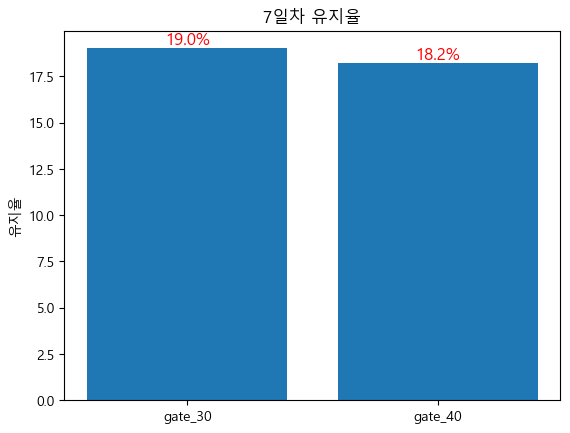

In [ ]:
rates = df.groupby("version")["retention_7"].mean() * 100

plt.bar(rates.index, rates.values)
for i, height in enumerate(rates.values):
    plt.text( i, height, f"{height:.1f}%", 
             ha='center', va='bottom', 
             size=12, color="red")
    
plt.ylabel("유지율")
plt.title("7일차 유지율")

plt.show()

In [25]:
from statsmodels.stats.proportion import proportions_ztest

g30 = df[df["version"]=="gate_30"]["retention_7"]
g40 = df[df["version"]=="gate_40"]["retention_7"]

count = np.array([g30.sum(), g40.sum()])
nobs = np.array([g30.count(), g40.count()])

z_stat, p_value = proportions_ztest(count, nobs)

print("z:", z_stat)
print("p-value:", p_value)

z: 3.1574100858819936
p-value: 0.0015917731773993442


|T-Test | Z-test |
| --- | --- |
| -모집단의 표준 편차가 알려져 있지 않고 표본 크기가 작을 때 사용 | -모집단의 표준 편차가 알려져 있거나 표본 크기가 큰 경우에 사용 |
|-데이터가 정규 분포를 따르고, 각 그룹 내에서 독립적이며, 그룹 간의 분산이 동일하다는 가정 등이 필요|-비슷한 가정을 필요하고 추가로 모집단의 표준 편차가 알려져 있거나 표본 크기가 충분히 크다는 가정이 필요|


z값 : 3.15 <- 표준오차의 약3.15배(평균 차이가 크다)  
>> ±1.96 → 95% 신뢰구간  
>> ±2.58 → 99% 신뢰구간  

p-value(0.001) < 0.05 : 귀무가설 기각

#### 결과 : 시작 위치 변경은 실제 유지율에 영향을 미친다.

### 3. 게임 시작 차이가 어디서 플레이스타일 유형에서 더 민감한가

In [26]:

df_1 = sdf_2.select(
    "version",
    "retention_1",
    "retention_7",
    "sum_gamerounds"
).toPandas()

In [27]:
df_1.sort_values(by='sum_gamerounds',ascending = True)

,version,retention_1,retention_7,sum_gamerounds
36,gate_40,0,0,1
29638,gate_40,0,0,1
63376,gate_30,0,0,1
63393,gate_40,0,0,1
63388,gate_40,0,0,1
...,...,...,...,...
44294,gate_30,1,1,2251
46057,gate_40,1,1,2294
41738,gate_30,1,1,2438
28122,gate_40,1,0,2640


In [28]:
def segment_rounds(x):
    if x <= 140:
        return "light"
    elif x <= 420:
        return "mid"
    else:
        return "hard"

df_1["playstyles"] = df_1["sum_gamerounds"].apply(segment_rounds)

In [29]:
df_1

,version,retention_1,retention_7,sum_gamerounds,playstyles
0,gate_30,0,0,3,light
1,gate_30,1,0,38,light
2,gate_40,1,0,165,mid
3,gate_40,0,0,1,light
4,gate_40,1,1,179,mid
...,...,...,...,...,...
86189,gate_40,1,0,97,light
86190,gate_40,0,0,30,light
86191,gate_30,1,0,28,light
86192,gate_40,1,0,51,light


In [30]:
seg_ret = (df_1.groupby(["playstyles","version"])
.agg(d1=("retention_1","mean"),
    d7=("retention_7","mean"))*100)
seg_ret.round(2)

d1     d7
playstyles version              
hard       gate_30  96.40  94.14
           gate_40  96.94  94.80
light      gate_30  41.75  13.37
           gate_40  41.20  12.52
mid        gate_30  91.21  75.40
           gate_40  90.97  75.38

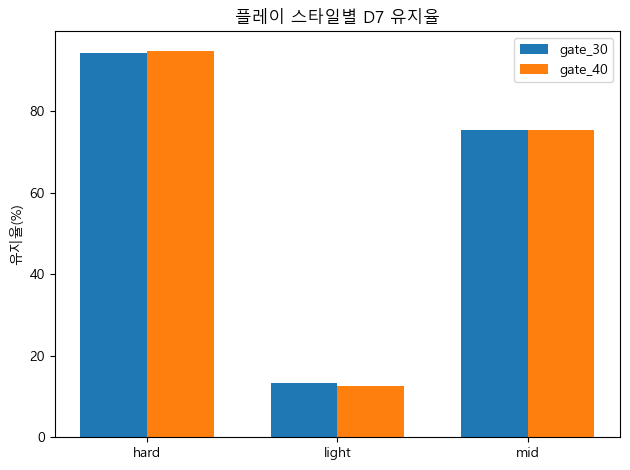

In [ ]:
seg_plot = seg_ret["d7"].unstack()

x = np.arange(len(seg_plot.index))
width = 0.35

plt.figure()
plt.bar(x - width/2, seg_plot["gate_30"], width, label="gate_30")
plt.bar(x + width/2, seg_plot["gate_40"], width, label="gate_40")

plt.xticks(x, seg_plot.index)
plt.ylabel("유지율(%)")
plt.title("플레이 스타일별 D7 유지율")
plt.legend()

plt.tight_layout()
plt.show()

#### 플레이스타이별 차이(gate_30 기준)
##### 하드 유저 : -0.66%(gate_40가 높음)  
-난이도 상승에 영향을 거의 받지 않음  
-오히려 관문이 뒤로 밀렸을 때 더 오래 남는 경향  
>하드유저는 도전 요소 증가에 내성이 강하다.    
##### 미드 유저 : +0.02%(거의 차이X, gate_30 ▲)    
-난이도 변경 영향이 거의 없음   
>미드 유저에겐 게임 전체 구조나 보상 설계가 더 중요할 것 같음.  
##### 라이트 유저 : +0.85%(gate_30가 높음)  
-난이도 상승에 영향을 많이 받음  
>라이트 유저에게 난이도 상승은 장기 잔존에 부정적이다.  

### 4. 이탈 유형

In [32]:
df["churn_type"] = np.select(
    [
        df["sum_gamerounds"].eq(0), #설치후 플레이 0회
        (df["retention_1"].eq(0) & df["retention_7"].eq(0)), #1일차,7일차에 접속X
        (df["retention_1"].eq(1) & df["retention_7"].eq(0)), #1일차만 접속
        (df["retention_1"].eq(1) & df["retention_7"].eq(1)), #1,7일차 접속O
    ],
    ["설치만", "1X,7X", "1X,7 O", "1 O,7 O"],
    default="1 O,7X"                                    #7일차만 접속
)

In [33]:
churn_rate = (df
              .groupby(["version","churn_type"])
              .size()
              .groupby(level=0, group_keys=False)
              .apply(lambda x: x / x.sum())
              .reset_index(name="rate"))

churn_rate["rate%"] = (churn_rate["rate"]*100).round(2)
churn_rate

,version,churn_type,rate,rate%
0,gate_30,"1 O,7 O",0.149332,14.93
1,gate_30,"1 O,7X",0.040493,4.05
2,gate_30,"1X,7 O",0.297948,29.79
3,gate_30,"1X,7X",0.468892,46.89
4,gate_30,설치만,0.043334,4.33
5,gate_40,"1 O,7 O",0.142936,14.29
6,gate_40,"1 O,7X",0.038779,3.88
7,gate_40,"1X,7 O",0.298336,29.83
8,gate_40,"1X,7X",0.474730,47.47
9,gate_40,설치만,0.045220,4.52


In [34]:
pivot = churn_rate.pivot(
    index="churn_type",
    columns="version",
    values="rate%"
)

In [35]:
pivot["diff"] = (
    pivot["gate_30"] - pivot["gate_40"]
).round(2)

In [36]:
pivot

version,gate_30,gate_40,diff
churn_type,,,
"1 O,7 O",14.93,14.29,0.64
"1 O,7X",4.05,3.88,0.17
"1X,7 O",29.79,29.83,-0.04
"1X,7X",46.89,47.47,-0.58
설치만,4.33,4.52,-0.19


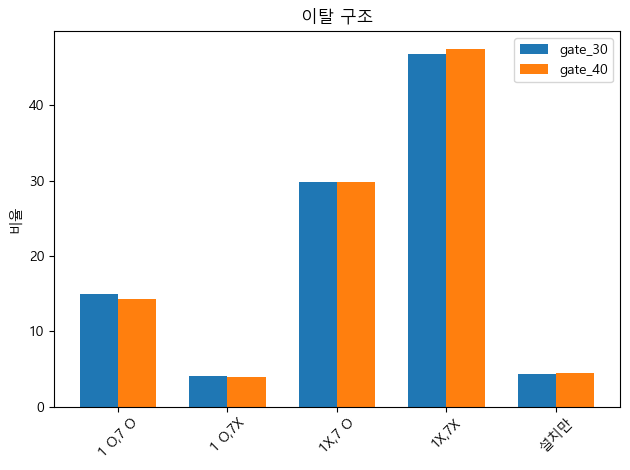

In [37]:
x = np.arange(len(pivot.index))
width = 0.35

plt.figure()
plt.bar(x - width/2, pivot["gate_30"], width, label="gate_30")
plt.bar(x + width/2, pivot["gate_40"], width, label="gate_40")

plt.xticks(x, pivot.index, rotation=45)
plt.ylabel("비율")
plt.title("이탈 구조")
plt.legend()

plt.tight_layout()
plt.show()

이탈 유형 분포 비교 결과,  
40레벨 시작한 그룹 경우  
**완전 유지 유저 비율은 감소**하고  
**지속 이탈 유형의 비율은 증가**

## 결론

- 초기 플레이 경험(D1 설계)은 장기 리텐션에 직접적인 영향을 미친다.  
- 난이도 조정은 모든 유저에게 동일하게 작용하지 않는다.  
- 라이트 유저를 고려한 초기 난이도 설계가 중요하다.  
------------------------------------------------------------
당연하게도 D1유지 여부는 **신규 유저의 첫 경험이 장기 잔존을 결정하는 핵심 포인트**라 생각한다.  
그렇기에 초반 허들은 **이탈 유도 요인**이 될 것이다.  
신규 유저 유입을 위해서는 **초반 성공 경험**, **난이도 완만한 상승 곡선 설계** 등과 같은 전략이 필요하다. 

## 한계점

- 14일 데이터만 존재하여 장기 LTV 분석 불가  
- 정교한 유저 행동 로그(세션 시간, 이탈 지점 등) 부족

## 정보 이용
- 데이터  
https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats  
- 게임 관련 데이터   
https://gamedevreports.substack.com/p/consumer-technology-association-almost  
- Spark 공부  
https://velog.io/@rymyung/Apache-Spark-%EC%A7%91%EA%B3%84-%ED%95%A8%EC%88%98  
https://sseozytank.tistory.com/98
- LTV란?  
https://blog.thebackend.io/key-success-indicator/  